## HiGLUE Preprocessing Tutorial

This tutorial outlines the preprocessing steps for preparing single-cell Hi-C and RNA-seq data for integration using HiGLUE. This includes only the main functionality; for more details, please run the full `higlue.py` script with `--preprocess` flag.

In [ ]:
import anndata as ad
import networkx as nx
import scanpy as sc
import scglue
import cooler
from cooler._logging import set_verbosity_level
import os
import sys
import itertools
import argparse
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from tqdm import tqdm
from networkx.algorithms.bipartite import biadjacency_matrix
from score.sc_args import parse_args
from score.utils.utils import sorted_nicely

In [22]:
n_strata = 10
loop_q = 0.99
n_genes = 5000
rna_file = '/mnt/jinstore/JinLab02/dmp131/scHi-C/HiRes_mouse_brain/hires_brain_rna.h5ad'
gtf_file = '/mnt/jinstore/JinLab02/dmp131/scHi-C/HiRes_mouse_brain/ref/gencode.vM25.annotation.gtf'


out_dir = 'data'
plot_dir = 'plots'
use_xy = False

os.makedirs(plot_dir, exist_ok=True)

In [23]:
parser = argparse.ArgumentParser()
sys.argv = ['SCORE', '',
            '--dset', 'hires_brain',
            '--scool', '/mnt/jinstore/JinLab02/dmp131/scHi-C/HiRes_mouse_brain/data/scools/hires_brain_500kb.scool',
            '--reference', '/mnt/jinstore/JinLab02/dmp131/scHi-C/HiRes_mouse_brain/hires_brain_ref',
            '--resolution', '500kb']
args, x, y, depths, batches, dataset, valid_dataset = parse_args(parser)

Dataset: hires_brain

Total Cells: 399

Cells before filtering: 399
Cells before filtering by chr: 399
not filtered : 398
chr_reads < chr_length : 1
Reference file with filtering criteria saved to data/hires_brain_filtered_ref


Ex1: 203

Ex2: 43

In1: 52

Ast: 20

Oli: 20

In2: 47

Ex3: 13

## Pseudo-bulk Hi-C generation

In [24]:
dataset_name = args.dset
resolution = args.resolution

cool_files = cooler.fileops.list_scool_cells(dataset.scool_file)
cool_files = [f"{dataset.scool_file}::{cell}" for cell in cool_files]
os.makedirs('data/scools', exist_ok=True)
out_cool_file = f"data/scools/{dataset_name}_{resolution}_bulk.cool"

try:
    bulk = cooler.Cooler(out_cool_file)
except Exception as e:
    print('Could not find bulk cooler file, generating from psuedobulk...')
    set_verbosity_level(1)
    cooler.merge_coolers(out_cool_file, cool_files, mergebuf=40000000)
    bulk = cooler.Cooler(out_cool_file)

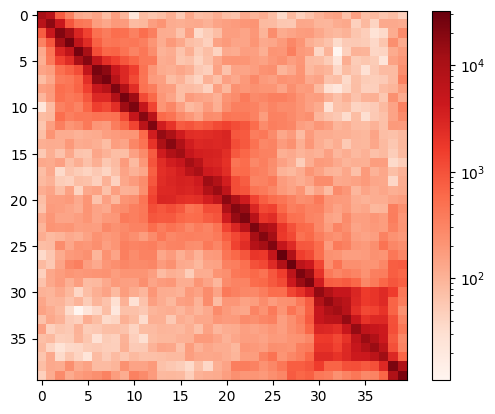

In [25]:
mat = bulk.matrix(balance=False).fetch('chr10')
midpoint = mat.shape[0] // 2
mat = mat[midpoint - n_strata * 2:midpoint + n_strata * 2, midpoint - n_strata * 2:midpoint + n_strata * 2]
plt.imshow(mat, cmap='Reds', norm=LogNorm())
plt.colorbar()
plt.show()

Now we filter to only the top loops which will be considered as edges in the prior graph.

In [31]:
frags = bulk.bins()[:]
frags.rename(columns={'start': 'chromStart', 'end': 'chromEnd'}, inplace=True)
frags['name'] = frags.index.astype(str)
loops = bulk.pixels(join=False)[:]
chr_map = frags['chrom'].to_dict()
start_map = frags['chromStart'].to_dict()
end_map = frags['chromEnd'].to_dict()
if not use_xy:
    frags = frags[~frags['chrom'].str.lower().str.contains('x|y')].reset_index(drop=True)
frags.rename(columns={'start': 'chromStart', 'end': 'chromEnd'}, inplace=True)

loops['chr1'] = loops['bin1_id'].map(chr_map)   
loops['chr2'] = loops['bin2_id'].map(chr_map)

loops['rank'] = loops['count'].rank(pct=True)
loops.dropna(inplace=True)

total_loops = loops.shape[0]
print(f"Total loops before filtering: {total_loops}")
loop_dfs = []
for chr_name in tqdm(sorted_nicely(bulk.chromnames)):
    if not use_xy and ('x' in chr_name.lower() or 'y' in chr_name.lower()):
        continue
    chr_loops = loops[(loops['chr1'] == chr_name) & (loops['chr2'] == chr_name)].copy()
    chr_loops['rank'] = chr_loops['count'].rank(pct=True)
    loop_cutoff = np.quantile(chr_loops['rank'].values, q=loop_q)
    chr_loops = chr_loops.loc[chr_loops['rank'] >= loop_cutoff].copy()
    chr_loops['rank'] = chr_loops['rank'].rank(pct=True)
    chr_loops.reset_index(drop=True, inplace=True)
    chr_loops.drop(columns=['chr1', 'chr2'], inplace=True)
    loop_dfs.append(chr_loops)
loops = pd.concat(loop_dfs).reset_index(drop=True)
print(loops.head())
print(f"Kept {loops.shape[0]} loops after filtering.")

Total loops before filtering: 13234598


100%|██████████| 21/21 [00:22<00:00,  1.05s/it]

   bin1_id  bin2_id  count      rank
0        0        0  12217  0.607710
1        0        1   8040  0.354875
2        0        2   4291  0.039683
3        1        1  14056  0.665533
4        1        2   6482  0.227891
Kept 7657 loops after filtering.


### RNA Preprocessing (same as GLUE)

/home/dmp131/anaconda3/envs/higlue/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


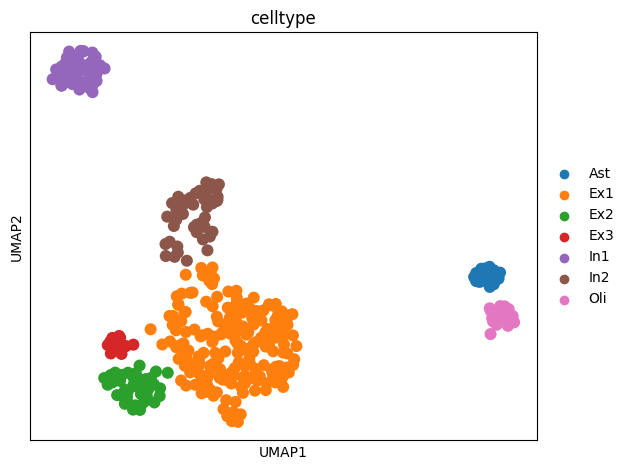

In [27]:
rna = ad.read_h5ad(rna_file)
try:
    rna.X = rna.layers["counts"]
except Exception as e:
    pass

if 'batch' not in rna.obs.columns:
    rna.obs['batch'] = 0
if 'celltype' not in rna.obs.columns:
    if 'cell_type' in rna.obs.columns:
        rna.obs['celltype'] = rna.obs['cell_type']
    else:
        rna.obs['celltype'] = 'Unknown'
rna.layers["counts"] = rna.X.copy()
keep_columns = scglue.genomics.Bed.COLUMNS
for col in keep_columns:
    try:
        rna.var.drop(columns=[col], inplace=True)
    except Exception as e:
        print(e)
        pass
try:
    scglue.data.get_gene_annotation(
        rna, gtf=gtf_file,
        gtf_by="gene_name"
    )
except KeyError:
    scglue.data.get_gene_annotation(
        rna, gtf=gtf_file,
        gtf_by="gene_symbol"
    )
    

rna.var['chromStart'] = rna.var['chromStart'].fillna(0).astype(int)
rna.var['chromEnd'] = rna.var['chromEnd'].fillna(0).astype(int)
rna.var['strand'] = rna.var['strand'].fillna('+')
rna = rna[:, rna.var['chrom'].notna()].copy()
try:
    if not rna.var['chrom'].iloc[0].startswith('chr'):
        rna.var['chrom'] = 'chr' + rna.var['chrom']
except AttributeError:
    print(rna.var['chrom'].iloc[0])
    print(rna.var['chrom'])

drop_cols = []
for col in rna.var.columns:
    if col not in keep_columns:
        drop_cols.append(col)
rna.var.drop(columns=drop_cols, inplace=True)
rna = rna[:, rna.var['chrom'].notna()].copy()
if not use_xy:
    rna = rna[:, ~rna.var['chrom'].str.lower().str.contains('x|y')].copy()
genes = scglue.genomics.Bed(rna.var.assign(name=rna.var_names))

sc.pp.filter_genes(rna, min_counts=1)
sc.pp.highly_variable_genes(rna, n_top_genes=n_genes, flavor="seurat_v3", span=1)
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.scale(rna)
sc.tl.pca(rna, n_comps=200, svd_solver="auto")
sc.pp.neighbors(rna, n_pcs=200, metric="cosine")
sc.tl.umap(rna)

fig = sc.pl.umap(rna, color=["celltype"], return_fig=True, wspace=0.6)
fig.tight_layout()
plt.show()

### scHi-C Preprocessing 

Loading scHi-C sparse matrices...


  0%|          | 0/398 [00:00<?, ?it/s]

100%|██████████| 398/398 [00:58<00:00,  6.81it/s]


Processing strata...
0 - Total interactions: 5,245 (5,245 from strata 0)
1 - Total interactions: 10,490 (5,245 from strata 1)
2 - Total interactions: 15,735 (5,245 from strata 2)
3 - Total interactions: 20,980 (5,245 from strata 3)
4 - Total interactions: 26,225 (5,245 from strata 4)
5 - Total interactions: 31,470 (5,245 from strata 5)
6 - Total interactions: 36,715 (5,245 from strata 6)
7 - Total interactions: 41,960 (5,245 from strata 7)
8 - Total interactions: 47,205 (5,245 from strata 8)
9 - Total interactions: 52,450 (5,245 from strata 9)
AnnData object with n_obs × n_vars = 398 × 52450
    obs: 'celltype', 'depth', 'batch', 'dataset'
    var: 'chrom', 'chromStart', 'chromEnd', 'target', 'target_chrom', 'target_chromStart', 'target_chromEnd'
    layers: 'counts'


/home/dmp131/anaconda3/envs/higlue/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


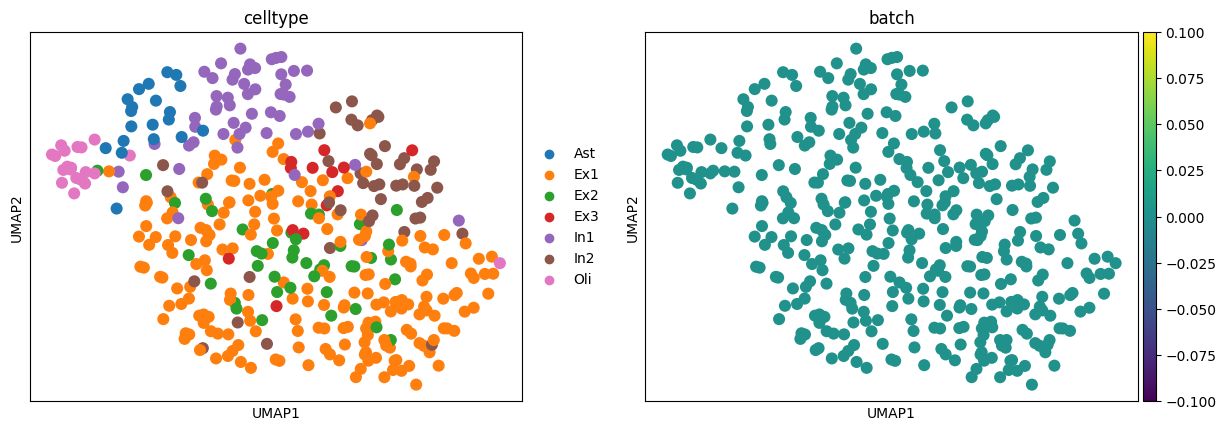

In [32]:
print('Loading scHi-C sparse matrices...')
mats = dataset.get_sparse_matrices()
mat = []
strata_adatas = []
total_interactions = 0
print(f'Processing strata...')
for k in range(n_strata):
    strata_mat = []
    for cell_i, cell in enumerate(sorted(dataset.cell_list)):
        new_strata = list(mats[cell_i].diagonal(k=k))
        if len(new_strata) < len(dataset.anchor_list):
            new_strata += [0] * (len(dataset.anchor_list) - len(new_strata))
        if resolution in ['10kb', '20kb', '50kb']:
            strata_mat.append(np.uint8(new_strata))
        else:
            strata_mat.append(new_strata)
    # create per-strata anndata
    strata_hic = ad.AnnData(np.array(strata_mat), dtype=np.uint8 if resolution in ['10kb', '20kb', '50kb'] else np.int32)
    strata_hic.obs_names = sorted(dataset.cell_list)
    strata_hic.obs_names = strata_hic.obs_names.map(lambda s: s.replace(f'.{dataset.res_name}', ''))
    genomic_pos = dataset.anchor_list.apply(lambda row: f"{row['chr']}:{row['start']}-{row['end']}", axis=1)
    if k == 0:
        strata_hic.var_names = genomic_pos
    else:
        if strata_hic.var_names.shape != genomic_pos.shape:
            strata_hic.var_names = genomic_pos.iloc[:-(k)] + f'-{k}'
        else:
            strata_hic.var_names = genomic_pos + f'-{k}'
    strata_hic.var['root'] = strata_hic.var_names.map(lambda s: s.rsplit('-', 1)[0] if (s[-2] == '-' or s[-3] == '-') else s)
    split = strata_hic.var['root'].str.split(r"[:-]")
    strata_hic.var["chrom"] = split.map(lambda x: x[0])
    strata_hic.var["chromStart"] = split.map(lambda x: x[1]).astype(int)
    strata_hic.var["chromEnd"] = split.map(lambda x: x[2]).astype(int)
    if not use_xy:
        strata_hic = strata_hic[:, ~strata_hic.var['chrom'].str.lower().str.contains('x|y')].copy()
    next_strata_map = frags.copy()
    next_strata_map['name'] = next_strata_map.apply(lambda row: f"{row['chrom']}:{row['chromStart']}-{row['chromEnd']}", axis=1)
    roots = next_strata_map['name'].values
    next_vars = np.roll(roots, shift=-k)
    next_vars[-k:] = roots[-k:]
    next_strata_map['target'] = next_vars
    next_strata_map = next_strata_map.set_index('name').to_dict()['target']

    strata_hic.var['target'] = strata_hic.var['root'].map(next_strata_map)
    split = strata_hic.var['target'].str.split(r"[:-]")
    strata_hic.var["target_chrom"] = split.map(lambda x: x[0])
    strata_hic.var["target_chromStart"] = split.map(lambda x: x[1]).astype(int)
    strata_hic.var["target_chromEnd"] = split.map(lambda x: x[2]).astype(int)

    if k > 0:  # keep all features for the first strata as roots for later, even if they have no interactions
        sc.pp.filter_genes(strata_hic, min_counts=0)
        sc.pp.filter_genes(strata_hic, min_cells=0)
    strata_hic.var.drop(columns=['root'], inplace=True)
    strata_adatas.append(strata_hic)
    total_interactions += strata_hic.shape[1]
    print(f'{k} - Total interactions: {total_interactions:,} ({strata_hic.shape[1]:,} from strata {k})')

hic = ad.concat(strata_adatas, axis=1, join='inner')
hic.layers["counts"] = hic.X.copy()
hic.obs['celltype'] = np.array([dataset.reference.loc[cell + f'.{dataset.res_name}', 'cluster'] for cell in hic.obs_names])
hic.obs['depth'] = np.array([dataset.reference.loc[cell + f'.{dataset.res_name}', 'depth'] for cell in hic.obs_names])
hic.obs['batch'] = np.array([dataset.reference.loc[cell + f'.{dataset.res_name}', 'batch'] for cell in hic.obs_names])
hic.obs['dataset'] = 'train'

print(hic)
sc.pp.normalize_total(hic)
sc.pp.log1p(hic)
sc.pp.scale(hic)
sc.tl.pca(hic, n_comps=min(100, hic.shape[0]), svd_solver="auto")
sc.pp.neighbors(hic, n_pcs=min(100, hic.shape[0]), metric="cosine")
sc.tl.umap(hic)
fig = sc.pl.umap(hic, color=["celltype", "batch"], return_fig=True)
plt.show()

### Construct Guidance Graph

In [ ]:
genes = scglue.genomics.Bed(rna.var.assign(name=rna.var_names))
diagonal_mask = hic.var_names.map(lambda s: s[-2] != '-' and s[-3] != '-')
diagonal_anchors = hic.var[diagonal_mask]
peaks = scglue.genomics.Bed(diagonal_anchors.assign(name=hic.var_names[diagonal_mask]))
tss = genes.strand_specific_start_site()
promoters = tss.expand(2000, 0)

frags['peak_name'] = frags.apply(lambda row: f"{row['chrom']}:{row['chromStart']}-{row['chromEnd']}", axis=1)
sign_dict = {}
def sign_map(interval):
    if interval in sign_dict.keys():
        print(interval, sign_dict[interval])
        return sign_dict[interval]
    else:
        return 1

overlap_graph = scglue.genomics.window_graph(
    promoters, peaks, 0,
    attr_fn=lambda l, r, d: {
        "weight": 1.0,
        "type": "overlap",
        "sign": sign_map(r.name)
    }
)
overlap_graph = nx.DiGraph(overlap_graph)
print('Overlap #edges:', overlap_graph.number_of_edges())


bait_oe = loops[['bin1_id', 'bin2_id', 'rank']]

seq_loops = pd.DataFrame()
sorted_frags = frags.sort_values(by=['chrom', 'chromStart'])

bait_oe['bin1_id'] = bait_oe['bin1_id'].astype(str)
bait_oe['bin2_id'] = bait_oe['bin2_id'].astype(str)
bait_oe = bait_oe.dropna().reset_index(drop=True)

peak_map = frags.set_index('name')['peak_name'].to_dict()
start_map = frags.set_index('name')['chromStart'].to_dict()
end_map = frags.set_index('name')['chromEnd'].to_dict()

#peaks = frags.set_index('peak_name')
bait_oe['peak1'] = bait_oe['bin1_id'].map(peak_map)
bait_oe['peak2'] = bait_oe['bin2_id'].map(peak_map)
bait_oe = bait_oe.dropna().reset_index(drop=True)
bait_oe['start1'] = bait_oe['bin1_id'].map(start_map).astype(int)
bait_oe['start2'] = bait_oe['bin2_id'].map(start_map).astype(int)
bait_oe['end1'] = bait_oe['bin1_id'].map(end_map).astype(int)
bait_oe['end2'] = bait_oe['bin2_id'].map(end_map).astype(int)
bait_oe['mid1'] = (bait_oe['end1'] - bait_oe['start1']).abs()
bait_oe['mid2'] = (bait_oe['end2'] - bait_oe['start2']).abs()
bait_oe['dist'] = (bait_oe['mid1'] - bait_oe['mid2']).abs() / 2e6
bait_oe['peak1'] = bait_oe['peak1'].astype(str)
bait_oe['peak2'] = bait_oe['peak2'].astype(str)

bait_oe = bait_oe[['peak1', 'peak2', 'rank', 'dist']]

frags.index = frags['peak_name']
frags = scglue.genomics.Bed(frags)
bait_oe.rename(columns={'rank': 'weight'}, inplace=True)
pchic_graph = nx.from_pandas_edgelist(bait_oe, source="peak1", target="peak2", edge_attr=True, create_using=nx.DiGraph)


nx.set_edge_attributes(pchic_graph, "hic", "type")
nx.set_edge_attributes(pchic_graph, 1, "sign")
print('Hi-C #edges:', pchic_graph.number_of_edges())

gene_bait = scglue.genomics.window_graph(promoters, frags, 1000)

chrom_attr = {}
pos_attr = {}
type_attr = {}

rna.var["in_hic"] = biadjacency_matrix(gene_bait, genes.index).sum(axis=1) != 0
print('Genes in Hi-C', rna.var["in_hic"].sum())

o_prior = overlap_graph.copy()

hvg_reachable = scglue.graph.reachable_vertices(o_prior, rna.var.query("highly_variable").index)

hic.var["o_highly_variable"] = [item in hvg_reachable for item in hic.var_names]
print('Overlap variable Hi-C features', hic.var["o_highly_variable"].sum())

o_prior = scglue.graph.compose_multigraph(o_prior, o_prior.reverse())
for item in itertools.chain(hic.var_names, rna.var_names):
    try:
        if item[-2] == '-' and item.startswith('chr'):
            continue
    except Exception as e:
        pass
    o_prior.add_edge(item, item, weight=1.0, type="self-loop", sign=1)
nx.set_edge_attributes(o_prior, 1, "sign")
nx.set_edge_attributes(o_prior, 0.0, "dist")
o_prior = o_prior.subgraph(hvg_reachable)

print(pchic_graph)
pchic_graph = scglue.graph.compose_multigraph(pchic_graph, pchic_graph.reverse())

print('Composing overlap graph with Hi-C graph...')
dcq_prior = scglue.graph.compose_multigraph(o_prior, pchic_graph)
nx.set_edge_attributes(dcq_prior, 1, "sign")

hvg_reachable = scglue.graph.reachable_vertices(dcq_prior, rna.var.query("highly_variable").index)
hic.var["dcq_highly_variable"] = [item in hvg_reachable for item in hic.var_names]
keep_distal_mask = hic.var_names.map(lambda s: s[-2] == '-' or s[-3] == '-')
# set distal entries as highly variable too
hic.var["dcq_highly_variable"] = hic.var["dcq_highly_variable"] | keep_distal_mask  
# and keep all roots of distal entries if they aren't already 
distal_source = hic.var_names[keep_distal_mask].map(lambda s: s.rsplit('-', 1)[0]).values
keep_non_distal_mask = hic.var_names.isin(distal_source)
hic.var["dcq_highly_variable"] = hic.var["dcq_highly_variable"] | keep_non_distal_mask
print('Full Hi-C prior variable features:', hic.var["dcq_highly_variable"].sum())

for item in dcq_prior.nodes:
    if dcq_prior.has_edge(item, item):
        continue
    else:
        dcq_prior.add_edge(item, item, weight=1.0, type="self-loop", sign=1)

chrom_attr = {}
strata_attr = {}
pos_attr = {}
type_attr = {}
for n in tqdm(dcq_prior.nodes):
    if n in genes.index:
        type_attr[n] = 'RNA'
        row = genes.loc[n]
        strata_attr[n] = 0
    elif n in frags.index:
        type_attr[n] = 'Hi-C'
        row = frags.loc[n]
        strata_attr[n] = 0.0
    else:
        type_attr[n] = 'Hi-C'
        chr_split = str(n).split(':')
        row = {}
        row['chrom'] = str(chr_split[0])
        try:
            pos = chr_split[1].split('-')
            row['chromStart'] = int(pos[0])
        except Exception as e:
            print(n, chr_split, pos, e)
            row['chromStart'] = 0
        try:
            strata_attr[n] = int(str(n).split('-')[-1])
        except Exception as e:
            print(e)
            strata_attr[n] = 0
    chrom_attr[n] = str(row['chrom'])
    pos_attr[n] = int(row['chromStart'])

edge_ids = {}
for edge_i, e in enumerate(dcq_prior.edges):
    edge_ids[e] = edge_i
nx.set_edge_attributes(dcq_prior, edge_ids, "edge_id")


suffix = f'raw_{loop_q}'
suffix += f'_2d_{n_strata}'
print(suffix)
os.makedirs(os.path.join(out_dir, 'rna'), exist_ok=True)
os.makedirs(os.path.join(out_dir, 'hic'), exist_ok=True)
os.makedirs(os.path.join(out_dir, 'graphs'), exist_ok=True)

hic.write(f"{out_dir}/hic/hic_{resolution}_{suffix}.h5ad", compression="gzip")
rna.write(f"{out_dir}/rna/rna_{resolution}_{suffix}.h5ad", compression="gzip")

nx.set_node_attributes(dcq_prior, chrom_attr, "chrom")
nx.set_node_attributes(dcq_prior, pos_attr, "chrom_pos")
nx.set_node_attributes(dcq_prior, type_attr, "feature_type")
nx.write_graphml(dcq_prior, f"{out_dir}/graphs/dcq_prior_{resolution}_{suffix}.graphml.gz", edge_id_from_attribute='edge_id', named_key_ids=True)

window_graph: 100%|██████████| 34142/34142 [00:00<00:00, 63480.96it/s]


Overlap #edges: 34272
     bin1_id bin2_id      rank                    peak1  \
0          0       0  0.607710           chr1:1-3456727   
1          0       1  0.354875           chr1:1-3456727   
2          0       2  0.039683           chr1:1-3456727   
3          1       1  0.665533     chr1:3456728-3912944   
4          1       2  0.227891     chr1:3456728-3912944   
...      ...     ...       ...                      ...   
7652    2681    2681  0.891566  chr19:58926737-59380754   
7653    2682    2682  0.530120  chr19:59380755-59849819   
7654    2683    2683  0.096386  chr19:59849820-60310964   
7655    2684    2684  0.168675  chr19:60310965-60767918   
7656    2685    2685  0.349398  chr19:60767919-61227857   

                        peak2  
0              chr1:1-3456727  
1        chr1:3456728-3912944  
2        chr1:3912945-4366459  
3        chr1:3456728-3912944  
4        chr1:3912945-4366459  
...                       ...  
7652  chr19:58926737-59380754  
7653  chr19:5

/tmp/ipykernel_2341560/859874184.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bait_oe['bin1_id'] = bait_oe['bin1_id'].astype(str)
/tmp/ipykernel_2341560/859874184.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bait_oe['bin2_id'] = bait_oe['bin2_id'].astype(str)
window_graph: 100%|██████████| 34142/34142 [00:00<00:00, 72484.70it/s]
/tmp/ipykernel_2341560/859874184.py:75: FutureWarning: biadjacency_matrix will return a scipy.sparse array instead of a matrix in NetworkX 3.0
  rna.var["in_hic"] = 

Genes in Hi-C 34120
Overlap variable Hi-C features 2731
DiGraph with 4859 nodes and 7657 edges
Composing overlap graph with Hi-C graph...
Full Hi-C prior variable features: 52450


100%|██████████| 9969/9969 [00:00<00:00, 13324.47it/s]


raw_0.99_2d_10
